In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 데이터를 샘플링하고 드라이브에 저장
1. 데이터셋이 13GB 용량으로 너무 큼 (7,247장의 이미지)
2. 클래스 불균형: 클래스 1(뮤테란캡슐)의 bbox가 4144로 압도적으로 많음 → 모델이 특정 약에만 과적합(Overfitting)될 수 있음

⇨ 샘플링을하여 용량을 줄인다.

- 샘플링:
    1. 데이터가 가장 많은 클래스 1을 포함하여, 이미지당 객체 수를 고려해 클래스별 최대 300 bbox 개수로 제한
        - 희귀 클래스 본존을 위해 넘칠 수도 있음
    2. 이미지 기준이 아니라 JSON(라벨) 기준으로 데이터를 뽑아서
    이미지–라벨 짝이 깨지지 않게 함.
    3. 데이터가 적은 클래스(예: 3, 18, 45)는 최대한 보존하도록 설계

In [ ]:
# all_data.zip 압축 해제

import os
import zipfile

# 경로 설정
zip_path = "/content/drive/MyDrive/Colab Notebooks/스프린트/초급 프로젝트/all_data.zip"
extract_path = "/content/all_data"

# 압축 해제
if os.path.exists(zip_path):
    print(f"해제 시작: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"해제 완료: {extract_path}")
else:
    print(f"파일을 찾을 수 없습니다.: {zip_path}")

# 해제된 폴더 구조 확인
!ls -R /content/all_data | head -n 20

해제 시작: /content/drive/MyDrive/Colab Notebooks/스프린트/초급 프로젝트/all_data.zip
해제 완료: /content/all_data
/content/all_data:
all_data

/content/all_data/all_data:
annotations
class_count.txt
images
test_images

/content/all_data/all_data/annotations:
K-000250-000573-002483-006192_0_2_0_2_70_000_200.json
K-000250-000573-002483-006192_0_2_0_2_75_000_200.json
K-000250-000573-002483-006192_0_2_0_2_90_000_200.json
K-000250-000573-002483-012778_0_2_0_2_70_000_200.json
K-000250-000573-002483-012778_0_2_0_2_75_000_200.json
K-000250-000573-002483-012778_0_2_0_2_90_000_200.json
K-000250-000573-002483-019552_0_2_0_2_70_000_200.json
K-000250-000573-002483-019552_0_2_0_2_75_000_200.json
K-000250-000573-002483-019552_0_2_0_2_90_000_200.json
K-000250-000573-002483-022627_0_2_0_2_70_000_200.json


In [ ]:
# 샘플링

import os
import json
import shutil
import random
from collections import defaultdict

# 경로 설정
ZIP_EXTRACT_PATH = "/content/all_data/all_data"      # 압축 해제된 경로
SRC_JSON_DIR = os.path.join(ZIP_EXTRACT_PATH, "annotations")
SRC_IMG_DIR = os.path.join(ZIP_EXTRACT_PATH, "images")

# 저장할 구글 드라이브 새 경로
DRIVE_SAVE_ROOT = "/content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2"
DST_IMG_DIR = os.path.join(DRIVE_SAVE_ROOT, "images")
DST_JSON_DIR = os.path.join(DRIVE_SAVE_ROOT, "annotations")

# 폴더 생성
os.makedirs(DST_IMG_DIR, exist_ok=True)
os.makedirs(DST_JSON_DIR, exist_ok=True)

# 샘플링 설정
MAX_BBOX_PER_CLASS = 70     # 클래스별 최대 70개까지만 사용
random.seed(42)

json_files = [f for f in os.listdir(SRC_JSON_DIR) if f.endswith('.json')]
random.shuffle(json_files)

selected_json = []
current_cls_counts = defaultdict(int)

print(f"1. 데이터 샘플링 분석 중 (Target: {MAX_BBOX_PER_CLASS})...")

for j_file in json_files:
    with open(os.path.join(SRC_JSON_DIR, j_file), 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 이미지에 포함된 모든 클래스 ID 추출
    img_classes = [ann['category_id'] for ann in data.get('annotations', [])]

    # 포함된 알약 중 하나라도 아직 300개 미만인 클래스가 있다면 선택 -> 희귀 클래스 보존을 위함
    should_select = False
    for cls_id in img_classes:
        if current_cls_counts[cls_id] < MAX_BBOX_PER_CLASS:
            should_select = True
            break

    if should_select:
        img_info = data['images'][0]
        img_name = img_info['file_name']
        if os.path.exists(os.path.join(SRC_IMG_DIR, img_name)):
            selected_json.append(j_file)
            # 선택된 이미지 내 모든 객체 카운트 업데이트
            for cls_id in img_classes:
                current_cls_counts[cls_id] += 1

print(f"2. 샘플링 완료: 총 {len(selected_json)}장의 이미지가 선택되었습니다.")

# 파일 복사
print("3. 구글 드라이브로 파일 복사")
for i, j_file in enumerate(selected_json):
    shutil.copy2(os.path.join(SRC_JSON_DIR, j_file), os.path.join(DST_JSON_DIR, j_file))

    with open(os.path.join(SRC_JSON_DIR, j_file), 'r', encoding='utf-8') as f:
        temp_data = json.load(f)
    img_name = temp_data['images'][0]['file_name']
    shutil.copy2(os.path.join(SRC_IMG_DIR, img_name), os.path.join(DST_IMG_DIR, img_name))

    if (i + 1) % 500 == 0:
        print(f"진행 상황: {i + 1}/{len(selected_json)}")

print(f"완료! 경로: {DRIVE_SAVE_ROOT}")

1. 데이터 샘플링 분석 중 (Target: 70)...
2. 샘플링 완료: 총 2162장의 이미지가 선택되었습니다.
3. 구글 드라이브로 파일 복사
진행 상황: 500/2162
진행 상황: 1000/2162
진행 상황: 1500/2162
진행 상황: 2000/2162
완료! 경로: /content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2


In [ ]:
# 데이터 무결성 확인

import os

# 데이터셋 경로 설정
PILL_DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2"
IMG_DIR = os.path.join(PILL_DATASET_ROOT, "images")
JSON_DIR = os.path.join(PILL_DATASET_ROOT, "annotations")

# 확장자를 제외한 파일 목록 및 이름 추출
img_files = {os.path.splitext(f)[0] for f in os.listdir(IMG_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))}
json_files = {os.path.splitext(f)[0] for f in os.listdir(JSON_DIR) if f.lower().endswith('.json')}

# 결과 분석
print(f"총 이미지 개수: {len(img_files)}")
print(f"총 JSON 개수: {len(json_files)}")

# 개수 및 파일명 일치 여부 확인
if img_files == json_files:
    print(f"\n모든 이미지와 JSON 파일이 1:1로 완벽하게 매칭됨")
else:
    print(f"\n파일 목록이 일치하지 않음.")

    # 누락된 파일 찾기
    missing_json = img_files - json_files
    missing_img = json_files - img_files

    if missing_json:
        print(f"JSON이 없는 이미지 ({len(missing_json)}개): {list(missing_json)[:5]}...")
    if missing_img:
        print(f"이미지가 없는 JSON ({len(missing_img)}개): {list(missing_img)[:5]}...")

총 이미지 개수: 2162
총 JSON 개수: 2162

모든 이미지와 JSON 파일이 1:1로 완벽하게 매칭됨


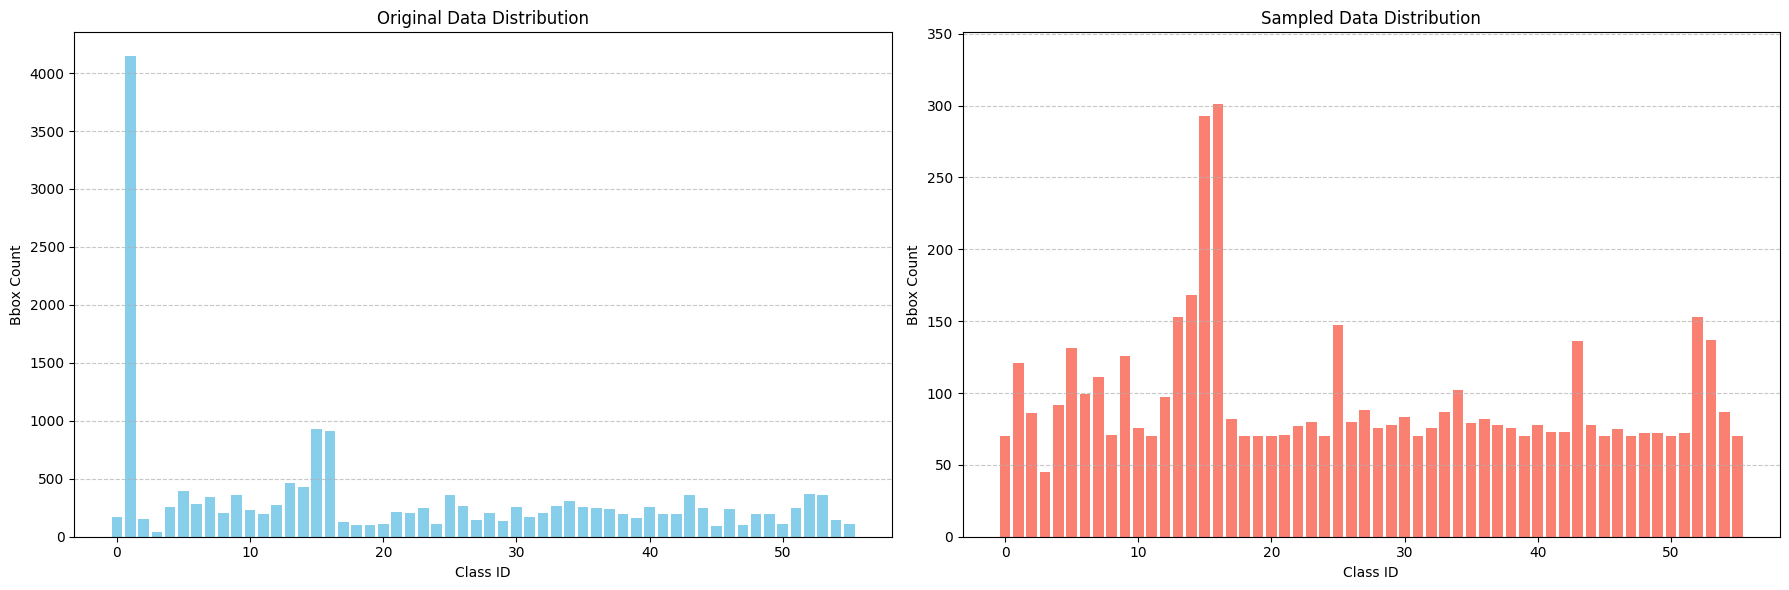

Total Bboxes (원본): 17824
Total Bboxes (샘플링 후): 5358
Class 1 Reduction: 4144 -> 121


In [ ]:
# 샘플링 후 데이터 분포 변화

import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# 샘플링 전 데이터 분포
original_counts = {
    0: 170, 1: 4144, 2: 153, 3: 45, 4: 258, 5: 392, 6: 284, 7: 341, 8: 204, 9: 359,
    10: 227, 11: 198, 12: 276, 13: 463, 14: 433, 15: 932, 16: 914, 17: 125, 18: 99, 19: 103,
    20: 107, 21: 213, 22: 205, 23: 247, 24: 106, 25: 356, 26: 264, 27: 148, 28: 206, 29: 135,
    30: 259, 31: 171, 32: 204, 33: 261, 34: 306, 35: 257, 36: 251, 37: 241, 38: 198, 39: 159,
    40: 253, 41: 193, 42: 192, 43: 358, 44: 252, 45: 96, 46: 239, 47: 101, 48: 198, 49: 199,
    50: 106, 51: 245, 52: 369, 53: 359, 54: 144, 55: 106
}

# 샘플링 후 데이터
SAMPLING_JSON_DIR = "/content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2/annotations"
sampled_counts = defaultdict(int)

json_files = [f for f in os.listdir(SAMPLING_JSON_DIR) if f.endswith('.json')]

for j_file in json_files:
    with open(os.path.join(SAMPLING_JSON_DIR, j_file), 'r', encoding='utf-8') as f:
        data = json.load(f)
    for ann in data.get('annotations', []):
        cls_id = ann['category_id']
        sampled_counts[cls_id] += 1

# 시각화
classes = sorted(original_counts.keys())
orig_values = [original_counts[c] for c in classes]
sampled_values = [sampled_counts.get(c, 0) for c in classes]

plt.figure(figsize=(18, 6))

# 샘플링 전 그래프
plt.subplot(1, 2, 1)
plt.bar(classes, orig_values, color='skyblue')
plt.title("Original Data Distribution")
plt.xlabel("Class ID")
plt.ylabel("Bbox Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 샘플링 후 그래프
plt.subplot(1, 2, 2)
plt.bar(classes, sampled_values, color='salmon')
plt.title("Sampled Data Distribution")
plt.xlabel("Class ID")
plt.ylabel("Bbox Count")
plt.ylim(0, max(sampled_values) + 50)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Total Bboxes (원본): {sum(orig_values)}")
print(f"Total Bboxes (샘플링 후): {sum(sampled_values)}")
print(f"Class 1 Reduction: {original_counts[1]} -> {sampled_counts[1]}")

# 클래스 불균형이 완전히 해결되진 않았지만 원본 데이터 대비 낮다. 15, 16이 많은 이유는 멀티 객체 특성상 희귀 클래스를 보존하는 과정에서 15, 16이 같이 추출되었기 때문으로 보인다.

In [ ]:
import os
import json
from tqdm import tqdm

# 샘플링된 데이터가 저장된 드라이브 경로
CHECK_JSON_DIR = "/content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2/annotations"

bad_files = []

print("BBox 개수 유효성 검사 시작...")
json_files = [f for f in os.listdir(CHECK_JSON_DIR) if f.endswith('.json')]

for j_file in json_files:
    file_path = os.path.join(CHECK_JSON_DIR, j_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        try:
            data = json.load(f)
            for ann in data.get('annotations', []):
                bbox = ann.get('bbox', [])
                # bbox가 리스트가 아니거나 길이가 4가 아닌 경우 적발
                if not isinstance(bbox, list) or len(bbox) != 4:
                    bad_files.append({
                        "file_name": j_file,
                        "wrong_bbox": bbox,
                        "length": len(bbox) if isinstance(bbox, list) else "Not a list"
                    })
        except Exception as e:
            print(f"파일 읽기 오류 ({j_file}): {e}")

# 결과 출력
print(f"총 {len(bad_files)}개의 불량 객체")
print("-" * 50)

if bad_files:
    for i, item in enumerate(bad_files[:10]): # 너무 많을 수 있으니 상위 10개만 출력
        print(f"[{i+1}] 파일명: {item['file_name']}")
        print(f"    ㄴ 실제 bbox 값: {item['wrong_bbox']} (길이: {item['length']})")

    if len(bad_files) > 10:
        print(f"... 외 {len(bad_files) - 10}개의 오류가 더 있습니다.")
else:
    print("모든 파일의 BBox가 유효함")

BBox 개수 유효성 검사 시작...
총 7개의 불량 객체
--------------------------------------------------
[1] 파일명: K-003544-016551-029451-033878_0_2_0_2_90_000_200.json
    ㄴ 실제 bbox 값: [146, 259, 211.202] (길이: 3)
[2] 파일명: K-003614-027777-031885-036637_0_2_0_2_75_000_200.json
    ㄴ 실제 bbox 값: [43, 14392, 503] (길이: 3)
[3] 파일명: K-003832-016232-033026_0_2_0_2_70_000_200.json
    ㄴ 실제 bbox 값: [632, 193, 190] (길이: 3)
[4] 파일명: K-003614-016232-025469-030308_0_2_0_2_75_000_200.json
    ㄴ 실제 bbox 값: [46.805, 368, 248] (길이: 3)
[5] 파일명: K-011220-020238-027653-030308_0_2_0_2_90_000_200.json
    ㄴ 실제 bbox 값: [59, 112402, 405] (길이: 3)
[6] 파일명: K-005094-005886-019552-044834_0_2_0_2_70_000_200.json
    ㄴ 실제 bbox 값: [544, 586.314, 500] (길이: 3)
[7] 파일명: K-005000-016262-018147_0_2_0_2_70_000_200.json
    ㄴ 실제 bbox 값: [111, 203291, 393] (길이: 3)


In [ ]:
# YOLO 학습용 데이터셋 빌드(JSON → TXT 변환)
import os
import json
import random
import yaml
from glob import glob
from pathlib import Path
from tqdm import tqdm

# 경로 설정
PILL_DATASET_ROOT = "/content/drive/MyDrive/Colab Notebooks/스프린트/pill_dataset_v2"
SRC_IMG_DIR = os.path.join(PILL_DATASET_ROOT, "images")
SRC_JSON_DIR = os.path.join(PILL_DATASET_ROOT, "annotations")

# YOLO 최종 결과물 경로 (로컬에 생성 후 필요시 드라이브 복사)
YOLO_ROOT = "/content/yolo_pill_dataset_v2"
VAL_RATIO = 0.2  # 8:2 분할
SEED = 42

# 클래스 매핑 (category_id -> class_id)
ORIG2CLS = {
    1900: 0, 2483: 1, 3351: 2, 3483: 3, 3544: 4, 3743: 5, 3832: 6, 4543: 7,
    12081: 8, 12247: 9, 12778: 10, 13395: 11, 13900: 12, 16232: 13, 16262: 14,
    16548: 15, 16551: 16, 16688: 17, 18147: 18, 18357: 19, 19232: 20, 19552: 21,
    19607: 22, 19861: 23, 20014: 24, 20238: 25, 20877: 26, 21325: 27, 21771: 28,
    22074: 29, 22347: 30, 22362: 31, 24850: 32, 25367: 33, 25438: 34, 25469: 35,
    27733: 36, 27777: 37, 27926: 38, 27993: 39, 28763: 40, 29345: 41, 29451: 42,
    29667: 43, 30308: 44, 31863: 45, 31885: 46, 32310: 47, 33009: 48, 33208: 49,
    33880: 50, 34597: 51, 35206: 52, 36637: 53, 38162: 54, 41768: 55
}

def process_jsons(jsons, split):
    for jp in tqdm(jsons, desc=f"Processing {split}"):
        with open(jp, 'r', encoding='utf-8') as f:
            data = json.load(f)

        img_info = data['images'][0]
        width, height = img_info['width'], img_info['height']
        file_name = img_info['file_name']
        stem = Path(file_name).stem

        # YOLO 라벨 작성
        lines = []
        for ann in data.get('annotations', []):
            bbox = ann.get('bbox', [])
            # bbox 유효성 검사 (4개가 아니면 무시)
            if not isinstance(bbox, list) or len(bbox) != 4:
                continue

            x, y, w, h = bbox
            # category_id 처리
            cat_id = ann['category_id']
            class_id = ORIG2CLS[cat_id] if cat_id in ORIG2CLS else cat_id

            # YOLO 정규화 좌표 계산
            # bbox: [x, y, w, h] -> YOLO: [x_center, y_center, w, h]
            xc = (x + w / 2) / width
            yc = (y + h / 2) / height
            wn = w / width
            hn = h / height
            lines.append(f"{class_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")

        # 유효한 라벨이 하나라도 있는 경우에만 파일 생성
        if lines:
            src_img = os.path.join(SRC_IMG_DIR, file_name)
            dst_img = os.path.join(YOLO_ROOT, 'images', split, file_name)

            if os.path.exists(src_img):
                if not os.path.exists(dst_img):
                    os.symlink(src_img, dst_img)

                label_path = os.path.join(YOLO_ROOT, 'labels', split, f"{stem}.txt")
                with open(label_path, 'w') as f:
                    f.write("\n".join(lines))

def build_yolo_dataset():
    # 폴더 생성
    for split in ['train', 'val']:
        os.makedirs(os.path.join(YOLO_ROOT, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(YOLO_ROOT, 'labels', split), exist_ok=True)

    # 데이터 분할
    json_paths = sorted(glob(os.path.join(SRC_JSON_DIR, "*.json")))
    random.seed(SEED)
    random.shuffle(json_paths)

    num_val = int(len(json_paths) * VAL_RATIO)
    val_jsons = json_paths[:num_val]
    train_jsons = json_paths[num_val:]

    process_jsons(train_jsons, 'train')
    process_jsons(val_jsons, 'val')

# data.yaml 생성 (56개 클래스 이름 자동 생성)
    yaml_content = {
        'path': YOLO_ROOT,
        'train': 'images/train',
        'val': 'images/val',
        'names': {v: f"Pill_{v}" for k, v in ORIG2CLS.items()}
    }

    with open(os.path.join(YOLO_ROOT, 'data.yaml'), 'w', encoding='utf-8') as f:
        yaml.dump(yaml_content, f, allow_unicode=True)

    print(f"\nYOLO 데이터셋 빌드 경로: {YOLO_ROOT}")

# 실행
build_yolo_dataset()

Processing val: 100%|██████████| 432/432 [00:01<00:00, 318.36it/s]


YOLO 데이터셋 빌드 경로: /content/yolo_pill_dataset_v2


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00


In [ ]:
# # YOLO26와 YOLOv8의 크기별 비교

from ultralytics import YOLO
import os

model_variants = [
    'yolo26n.pt', 'yolo26s.pt', 'yolo26m.pt',
    'yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt'
]

# 공통 학습 설정 (Architect's Standard)
common_cfg = {
    'data': '/content/yolo_pill_dataset_v2/data.yaml',
    'epochs': 15,
    'imgsz': 640,          # 비교를 위한 표준 해상도
    'batch': 16,
    'optimizer': 'AdamW',
    'project': 'Pill_Benchmark_v2',
    'device': 0
}

# 순차적 학습 및 성능 기록
results_summary = {}

for model_name in model_variants:
    print(f"\n학습 중인 모델: {model_name}")

    # 모델 초기화
    model = YOLO(model_name)

    # 학습 실행
    results = model.train(name=model_name.split('.')[0], **common_cfg)

    # mAP50-95 기록
    results_summary[model_name] = results.results_dict['metrics/mAP50-95(B)']

print("\n실험 완료")
for model, map_score in results_summary.items():
    print(f"[{model}] mAP50-95: {map_score:.4f}")


학습 중인 모델: yolo26n.pt
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_pill_dataset_v2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

In [ ]:
# best 모델로 바운딩 박스 예측 후 시각화
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

def run_inference(model_path, img_path):

    model = YOLO(model_path)

    results = model.predict(source=img_path, conf=0.25, imgsz=768)

    res_plotted = results[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"결과: {os.path.basename(model_path)}")
    plt.show()

model_path = ''
img_path = ''
run_inference(model_path, img_path)